# Driven Diffusion in 1D (cylindrical geometry)

What is the concentration profile $c(z)$ if particles are injected at $z=0$ with current density $j_0$ and at $z=L$ the particles are removed into the bulk at concentration $c_0$, assuming steady state, i.e., $\frac{\partial c}{\partial t} = 0$?

We assume Fick's law for the current

$$
j = -D \nabla c
$$

with the diffusion coefficient $D$. For simplicity, we will assume that $D$ is constant and does not depend on position.

The concentration $c(t, \mathbf{r})$ obeys the diffusion equation 
\begin{equation}
\frac{\partial c}{\partial t} = D\nabla^2 c
\end{equation}
without sources or sinks. (Note that we will be injecting protons on the _boundary_ of the problem, so no sources, and protons will leave at the other boundary, so no sinks.)

We are looking for the steady state


$$
\frac{\partial c}{\partial t} = 0
$$

so there will no time dependence and we will solve Laplace's equation
$$
\nabla^2 c = 0
$$

## Cylindrical geometry

We assume a cylindrical geometry. The Laplacian in cylindrical coordinates $\rho, \phi, z$ is

$$
\nabla^2 c  = \frac{1}{\rho}\frac{\partial}{\partial \rho}\left(\rho \frac{\partial c}{\partial \rho}\right) + \frac{1}{\rho^2}\frac{\partial^2 c}{\partial \phi^2} + \frac{\partial^2 c}{\partial z^2}
$$

### Simplification under rotational symmetry and no radial dependence

If we assume that:
1. **Rotational symmetry**: $c(\rho, \phi, z) = c(\rho, z)$ (no $\phi$ dependence)
2. **No radial dependence**: $c(\rho, z) = c(z)$ (no $\rho$ dependence)

Then the Laplacian simplifies as follows:

**Step 1: Rotational symmetry** eliminates the azimuthal term:
$$\frac{\partial^2 c}{\partial \phi^2} = 0$$

**Step 2: No radial dependence** means $\frac{\partial c}{\partial \rho} = 0$, so the radial term becomes:
$$\frac{1}{\rho}\frac{\partial}{\partial \rho}\left(\rho \frac{\partial c}{\partial \rho}\right) = \frac{1}{\rho}\frac{\partial}{\partial \rho}(\rho \cdot 0) = 0$$

**Radial boundary conditions for consistency:**

For the assumption $\frac{\partial c}{\partial \rho} = 0$ to be physically consistent, we need:

1. **At the center** ($\rho = 0$): The concentration must be finite and the radial derivative must vanish (regularity condition):
   $$\left.\frac{\partial c}{\partial \rho}\right|_{\rho=0} = 0$$

2. **At the cylindrical boundary** ($\rho = R$): We need a **no-flux** boundary condition:
   $$\left.\frac{\partial c}{\partial \rho}\right|_{\rho=R} = 0$$
   
   This ensures that no particles cross the cylindrical wall, making the radial current $j_\rho = -D\frac{\partial c}{\partial \rho} = 0$ at the boundary.

These boundary conditions are **automatically satisfied** when $c$ has no $\rho$ dependence, making our 1D assumption self-consistent.

Therefore, the problem reduces to the **1D case**:
$$
\frac{\partial^2 c}{\partial z^2} = 0.
$$


## Methods

### Boundary conditions

1. Bulk at $z=L$

   $$
   c(z=L) = c_0
   $$

   We assume instantaneous absorption.

3. Particles enter at $z=0$ with a constant current density $j_0$ (using Fick's law $j = -D\partial_z c$)

   $$
   \left.\frac{\partial c}{\partial z}\right|_{z=0} = -\frac{j_0}{D}
   $$

      
   

   


### Analytical solution

Solving Laplace's equation with the boundary conditions yields 

$$
c(z) = c_0 + \frac{j_0}{D}(L - z) = c_0\left[1 + \frac{j_0}{D c_0}(L - z)\right]
$$

a simple linear profile.

We use `sympy` to work with the equations:

In [1]:
import sympy as sm
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
z, k, c0, D, L, j0 = sm.symbols("z,k,c_0,D,L,j_0")
N_A, n, x = sm.symbols("N_A, n, x")

Analytical solution

In [3]:
c = c0 + j0/D * (L-z)
c

c_0 + j_0*(L - z)/D

### Increased figure resolution
When outputting figures as PNG (e.g., when exporting the notebook to PDF via LaTeX) we want to set the resolution to at least 300 dpi; however, for working in the notebook, this is not convenient as the figures show up to large.

In [4]:
#%matplotlib inline
#import matplotlib as mpl
#mpl.rcParams['figure.dpi'] = 300

On modern displays, you can always enable higher resolution display figures (can be done in addition to the dpi increase).

In [5]:
%config InlineBackend.figure_format = 'retina'

## Results: Concentration profile with realistic parameters

units: nm, ps 

Convert mol to numbers by multiplying with $N_A$

* Unit of $j_0$ is $\text{time}^{-1}\, \text{length}^{-2}$.
* Unit of $D$ is $\text{length}^{2}\, \text{time}^{-1}$.

| parameter | value | value (nm, ps)     |
|-----------|-------|--------------------|
|    $c_0$  | pH 7.2  |  $2.3326612721888007 \times 10^{-8}\,\mathrm{nm}^{-3}$|
| $D_{H^+}$ | $7000\ \text{µm}^2/\text{s}$ | $7 \times 10^{-3} \text{nm}^2/\text{ps}$ |
| $D_{H^+}$ | $9.3 \times 10^{-5}\ \text{cm}^2/\text{s}$ | $9.3 \times 10^{-3} \text{nm}^2/\text{ps}$ |
| $D_\mathrm{eff}$ | $D_{H^+} / 10^{4}$ | $9.3 \times 10^{-7} \text{nm}^2/\text{ps}$ |
| $L$       | 9.5 nm  |   9.5 nm             |
| $k_{\mathrm{H}^+}$ | 1 ms $^{-1}$ | $1\times 10^{-9}\,\mathrm{ps}^{-1}$ |
| $j_0$     | $k_{\mathrm{H}^+}$ @ radius $r=3$ Å |  $k_{\mathrm{H}^+}/(π r^2) = 3.53 \times 10^{-9}\,\mathrm{ps}^{-1}\cdot\mathrm{nm}^{-2}$ |

pH: Theillet FX et al., Physicochemical properties of cells and their effects on intrinsically disordered proteins (IDPs). Chem Rev. 2014 Jul 9 114(13):6661-714. doi: 10.1021/cr400695p p.6663 (via [bionumbers 115761](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=115761)

Proton diffusion coefficient: 

* 7000 µm $^2$/sec (from [BioNumbers ID 106702](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=106702)) = $7 \times 10^3 (10^3 \text{nm})^2 / 10^{12} \text{ps} = 7 \times 10^{-3} \text{nm}^2/\text{ps}$ 
* $9.3\times 10^{-5}\ \text{cm}^2/\text{s}$ from Lee et al manuscript (extended data)
  

### Functions

For convenience, we define functions to set up the solution with ranges of specific parameters.

* `solve_c()`: return equations with numerical values for parameters (in particular, $k$)
* `plot_c()`: solve equations and then plot concentration $c(z)$ and local pH profile for a given parameter set as given as keyword arguments
* `plot_range()`: solve and plot a *quantity* (either `"c"` or `"pH"`) for a range of values for a specific *parameter*

In [6]:
import sympy as sm
import scipy

# conversions
x, n, pH, N_A = sm.symbols("x, n, pH, N_A")
fromMolar = x * N_A / 1e24
toMolar = n / N_A * 1e24
from_pH = fromMolar.subs(x, 10**(-pH))
to_pH = -sm.log(toMolar, 10)

N_A = sm.symbols("N_A")
constants = {N_A: scipy.constants.Avogadro}


def solve_c(L_nm=2, bulk_pH=7.2, k_proton=1, D_proton=9.3e-3):
    N_A = sm.symbols("N_A")
    z, c0, D, L, j0 = sm.symbols("z,c_0,D,L,j_0")
    kH, rH, pH = sm.symbols("k_H, r_H, pH")
    constants = {N_A: scipy.constants.Avogadro}

    proton_transport = {kH: k_proton * 1e-9,   # proton transport rate in ms^-1, convert to ps^-1
                        rH: 0.3, # radius of exit pathway in nm
                        pH: bulk_pH,   # bulk solution pH
                       }

    parameters = {L: L_nm, 
                  j0: kH/(sm.pi * rH**2), 
                  c0: from_pH,       # pH -> c0
                  D: D_proton,       # proton diffusion coefficient
              }   

    c = c0 + j0/D * (L-z)

    concentration_z = {"func": toMolar.subs(n, c.subs(parameters)
                  .subs(proton_transport))
                  .subs(constants),
                     "range": (z, 0, L.subs(parameters)),
                    }
    pH_z = {"func": to_pH.subs(n, c.subs(parameters)
                                .subs(proton_transport))
                      .subs(constants),
            "range": (z, 0, L.subs(parameters)),
           }
    return concentration_z, pH_z

    
def plot_c(**kwargs):
    c_z, pH_z = solve_c(**kwargs)

    sm.plotting.plot(c_z["func"], c_z["range"],
                     xlabel=r"$z$ (nm)", ylabel=r"$c(z)$ (mol/l)", size=(3,3))
    sm.plotting.plot(pH_z["func"], pH_z["range"],
                     xlabel=r"$z$ (nm)", ylabel=r"pH$(z)$", size=(3,3))
    

def plot_range(parameter, parameter_range, 
               quantity="pH",
               size=(4, 3),
               save=True,
               legend=True,
               **kwargs):
    pix = {'c': 0, 'pH': 1}   # index with quantity
    plabel = {'c': r"$c(z)$ (mol/l)", 'pH': r"pH$(z)$"}
    parameter_labels = {
        "k_proton": r"$k_{{\mathrm{{H}}^+}}={value}$ ms$^{{-1}}$",
        "L_nm": r"$L={value}$ nm",
        "bulk_pH": "bulk pH {value}",
        "D_proton": r"$D_{{\mathrm{{H}}^+}}={value:.1e}\,\mathrm{{nm}}^2\cdot\mathrm{{ps}}^{{-1}}$",
    }
    if save:
        filename = kwargs.pop("filename", 
                              f"protondiffusion_{quantity}_{parameter}.pdf")
    show = not save
    
    kw = kwargs.copy()
    functions = []
    label = []
    for value in parameter_range:
        kw[parameter] = value
        solution = solve_c(**kw)
        p = solution[pix[quantity]]
        functions.append((p["func"], p["range"]))
        label.append(parameter_labels[parameter].format(value=value))
    p1 = sm.plotting.plot(*functions,
                     xlabel=r"$z$ (nm)", ylabel=plabel[quantity], 
                     label=label, legend=legend,
                     show=show, 
                     size=size)
    if save:
        p1.save(filename)
        print(f"Saved to {filename}")
    return p1    


### Simplified cylindrical proton path model for TBC1D5/Rab7/NHE6 

The cylindrical 1D path (pink cylinder) roughly follows a possible proton path (red spheres) from D260 (proton binding site in NHE6) to H207 (proton sensor in TBC1D5). 

<!--
<img src="figs/TBC1D5_Rab7_NHE6_diffusion_cylinder_centered.jpg" alt="Cylindrical geometry in TBC1D5/Rab7/NHE6, leading from D260 to H207" style="width: 30%;">
-->

![Cylindrical geometry in TBC1D5/Rab7/NHE6, leading from D260 to H207](figs/TBC1D5_Rab7_NHE6_diffusion_cylinder_centered.jpg)

The dimensions of the cylindrical geometry are derived from the molecular model:

- Bulk "far" away $L=9.5$ nm
- ionizable residue near $z=7.5$ nm

We will assume that proton diffusion is slowed down by a factor $0 < \alpha \ll 1$, e.g. $\alpha = 10^{-4}$ 
- $D_\mathrm{eff} = \alpha D_{H^+}$

We assume

* protons diffuse through a straight tunnel that is connected to the bulk at $L=9.5\,\mathrm{nm}$ and bulk pH is 7.2; the only connection to the bulk is at the end of the tunnel
* protons diffuse at the reduced effective diffusion coefficient $D_\mathrm{eff}$
* the His 207 residue is located at about $z=7.5\,\mathrm{nm}$ along the pathway
* the system is in steady state (i.e., the influx of protons into the tunnel due to NHE6 equals the efflux of protons at the exit of the tunnel)


In [7]:
bulk_pH = 7.2
Lmax = 9.5
z_His207 = 7.5

D_proton_bulk = 9.3e-3

### Unrestricted proton production

NHE6 is assumed to transport protons from the endosome to the cytosol at the constant rate $k_\mathrm{proton}$, i.e., we do _not_ yet take into account that proton transport of NHE6 is likely restricted to a relatively narrow pH window (for other CPA transporters, this window is approximately $6.5 < \mathrm{pH} < 9$) and that transport towards the cytosol must be *thermodynamically* favored.

As we will see, there is no restriction on the proton production of the transporter, which will lead to unrealistically low pH at the proton source at $z=0$. We will address this point subsequently.

Saved to figs/protondiffusion_L=9.5nm.pdf


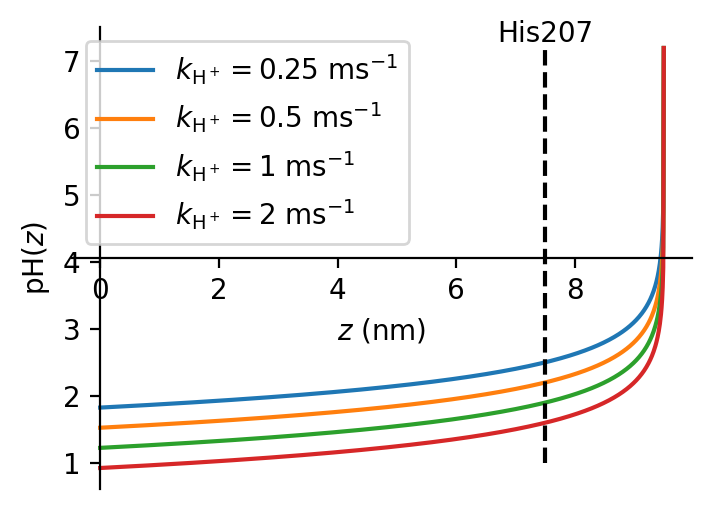

In [8]:
alpha=1e-4
filename = f"figs/protondiffusion_L={Lmax}nm.pdf"
plot_range("k_proton", (0.25, 0.5, 1, 2), L_nm=Lmax, 
           bulk_pH=bulk_pH, D_proton=alpha * D_proton_bulk,
           filename=filename)
plt.vlines(z_His207, 1, bulk_pH, color="k", linestyle="--")
plt.text(z_His207, bulk_pH, "His207", ha="center", va="bottom")
plt.savefig(filename)

The 1D confinement concentrates the protons inside the tunnel and hence only a modest decrease of of the diffusion coefficient by one tenth $D_\mathrm{eff} = \frac{1}{10} D_\mathrm{bulk}$ is needed to generate a local pH of about 5 near the His207 site:

Saved to figs/protondiffusion_L=9.5nm_D=tenthofbulk.pdf


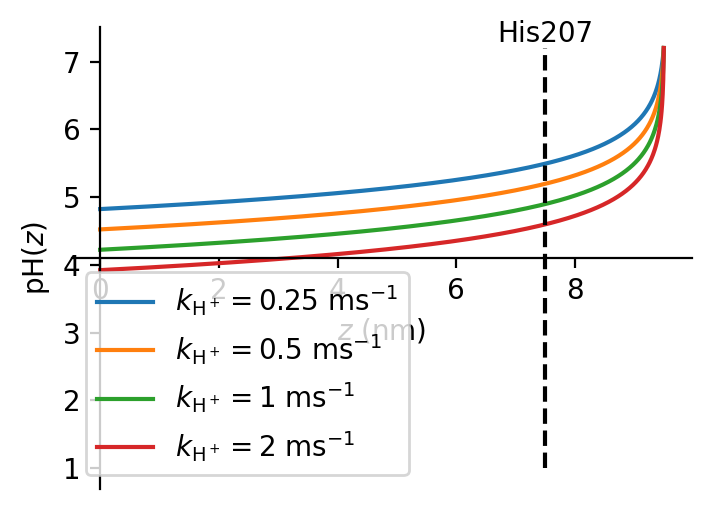

In [9]:
alpha = 1e-1
filename = f"figs/protondiffusion_L={Lmax}nm_D=tenthofbulk.pdf"
plot_range("k_proton", (0.25, 0.5, 1, 2), L_nm=Lmax, 
           bulk_pH=bulk_pH, D_proton=alpha * D_proton_bulk,
           filename=filename)
plt.vlines(z_His207, 1, bulk_pH, color="k", linestyle="--")
plt.text(z_His207, bulk_pH, "His207", ha="center", va="bottom")
plt.savefig(filename)


### NHE6 with thermodynamic limitation

In the following we will ignore the transporter activity window as we do not have experimental data for NHE6. We restrict ourselves to the thermodynamics of the transport process (see eg [Beckstein & Naughton 2022](https://pubmed.ncbi.nlm.nih.gov/35434715/)). 


#### Thermodynamis of 1:1 antiport

The commonly ascribed physiological role of NHE6 in endosomes is that of a leak pathway for protons that prevents over-acidification of the endosome and helps maintain the endosome pH. Therefore we are interested in the transport of protons from the inside of the endosome to the cytosol. We will denote transport in this direction with a negative sign and transport from the cytsol into the endosome with a positive sign. Thus moving one proton into the cytsol counts as $-1$ and one cation from the cytosol into the endosome as $+1$. 

Assuming pefect coupling between proton $\mathrm{H}^{+}$ and driving cation $\mathrm{X}^{+}$ transport in a 1:1 antiport stoichiometry, the free energy dissipation per transport cycle (where the $\Delta\mu$ are the electrochemical potential differences between inside (endosome) and outside (cytosol)) is
\begin{align}
\Delta G = 1 \Delta\mu_{\mathrm{X}^+} - 1 \Delta\mu_{\mathrm{H}^+} &< 0\\
kT \ln \frac{c^{\mathrm{in}}_{\mathrm{X}^+}}{c^{\mathrm{out}}_{\mathrm{X}^+}} - kT \ln \frac{c^{\mathrm{in}}_{\mathrm{H}^+}}{c^{\mathrm{out}}_{\mathrm{H}^+}} &< 0\\
\frac{c^{\mathrm{in}}_{\mathrm{X}^+}}{c^{\mathrm{out}}_{\mathrm{X}^+}} &< \frac{c^{\mathrm{in}}_{\mathrm{H}^+}}{c^{\mathrm{out}}_{\mathrm{H}^+}}
\end{align}
and because of the second law of thermodynamics, this dissipation must be negative (with our convention of signs [Beckstein & Naughton 2022](https://pubmed.ncbi.nlm.nih.gov/35434715/)) — i.e., the free energy available from the driving cation must be more negative than the energetic cost of the proton transport.

Thus the proton concentration on the outside (cytosolic side) has to obey
\begin{equation}
c^{\mathrm{out}}_{\mathrm{H}^+} < c^{\mathrm{in}}_{\mathrm{H}^+} \frac{c^{\mathrm{out}}_{\mathrm{X}^+}}{c^{\mathrm{in}}_{\mathrm{X}^+}}
\end{equation}
so that _any_ vectorial transport of protons from the ensosome to the cytosol is possible. (Note that this relation does not determine the actual rate of transport, $k_{\mathrm{H}^{+}}$, which requires a detailed kinetic analysis and requires more information about the individual steps of the transport cycle, see eg [Awtrey & Beckstein 2024](https://pubmed.ncbi.nlm.nih.gov/39160681/)).

Equivalently, the local pH must be
\begin{equation}
\mathrm{pH}^{\mathrm{out}} > \mathrm{pH}^{\mathrm{in}} - \log_{10} \frac{c^{\mathrm{out}}_{\mathrm{X}^+}}{c^{\mathrm{in}}_{\mathrm{X}^+}}
\end{equation}

#### Physiological concentrations and driving forces

For the late endosome and the cytosol, pH and ion concentrations are:

| ion | inside (late endosome) | outside (cytosol) | reference |
|-----|-------------------|-------------------|-----------|
| Na<sup>+</sup> | 20 - 140 mM        | ~12 mM          | Haoxing Xu and Dejian Ren, Lysosomal Physiology, Annu. Rev. Physiol. 2015. 77: 57–80 doi: [10.1146/annurev-physiol-021014-071649](https://doi.org/10.1146/annurev-physiol-021014-071649) via [bionumbers 117096](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=117096)   |
| K<sup>+</sup>  | 2 - 50 mM        | ~150 mM             | Haoxing Xu and Dejian Ren, Lysosomal Physiology, Annu. Rev. Physiol. 2015. 77: 57–80 doi: [10.1146/annurev-physiol-021014-071649](https://doi.org/10.1146/annurev-physiol-021014-071649) via [bionumbers 117096](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=117096)|
| H<sup>+</sup>  | pH 5.5-5.8        | pH 7.2             | Ma L, Ouyang Q, Werthmann GC, Thompson HM and Morrow EM (2017) Live-cell Microscopy and Fluorescence-based Measurement of Luminal pH in Intracellular Organelles. Front. Cell Dev. Biol. 5:71. doi: [10.3389/fcell.2017.00071](https://doi.org/10.3389/fcell.2017.00071); Theillet FX et al., Physicochemical properties of cells and their effects on intrinsically disordered proteins (IDPs). Chem Rev. 2014 Jul 9 114(13):6661-714. doi: [10.1021/cr400695p](https://doi.org/10.1021/cr400695p) p.6663 (via [bionumbers 115761](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=115761)) |



In [10]:
# extreme concentrations in mol/l
concentrations = {
    "Na+": {"in": 0.140, "out":0.012}, 
    "K+": {"in": 0.002, "out": 0.150},
    "H+": {"in": 10**(-5.5), "out": 10**(-7.2)}
    }

def driving_force_kT(c_in, c_out):
    """Thermodynamic driving force for a concentration gradient in units of kT"""
    return sm.log(c_in / c_out)

These concentrations indicate that protons would spontaneously move from the endosome to the cytosol. At first glance, no driving ion is needed because no thermodynamic driving force is needed for the energetically downhill spontaneous proton movement, although any additional driving force would accelerate proton transport.  

The free energy to move a proton from the outside to the inside would be

In [12]:
Xproton = driving_force_kT(concentrations["H+"]["in"], concentrations["H+"]["out"])
Xproton

3.91439465808988

which is positive and unfavorable. Hence moving the proton from the inside to the outside is favorable with the negative of this value 

In [13]:
-Xproton

-3.91439465808988

The gradient for sodium ions is _also_ directed from endosome to the cytsol, in the same direction as the proton gradient. Because of NHE6's antiporting mechanism, the sodium driving force 
\begin{equation}
\Delta\mu_{\mathrm{Na}^+} = kT \ln \frac{c^{\mathrm{in}}_{\mathrm{Na}^+}}{c^{\mathrm{out}}_{\mathrm{Na}^+}}
\end{equation}
will effectively _hinder_ proton movement. It's magnitude is

In [14]:
driving_force_kT(concentrations["Na+"]["in"], concentrations["Na+"]["out"])

2.45673577282130

Thus, the proton gradient can **drive accummulation of sodium into the endosome** and NHE6 would function as a proton-driven sodium transporter.

Farther below we will compute maximum cytosolic pH if only H+/Na+ transport.

NHE6 is know to also transport **potassium ions** (Gao AYL, Lourdin-De Filippis E, Orlowski J, McKinney RA. Roles of Endomembrane Alkali Cation/Proton Exchangers in Synaptic Function and Neurodevelopmental Disorders. Front Physiol. 2022 Apr 25;13. doi:
 [10.3389/fphys.2022.892196](https://doi.org/10.3389/fphys.2022.892196)) and the $\mathrm{K}^{+}$ gradient is directed from the cytosolic side towards the endosome and can thus drive proton efflux. Its magnitude is

In [15]:
driving_force_kT(concentrations["K+"]["in"], concentrations["K+"]["out"])

-4.31748811353631

This is a strong thermodynamic driving force that can additionally **drive proton export into the cytosol**.

The proton and potassium gradients *favor transport cycles that export protons*. Only sodium transport is energetically uphill.

### Transport of a single cation

Under the assumption that only one cation drives the transport, the cytosolic concentration of proton near the exit 
\begin{equation}
c^{\mathrm{out}}_{\mathrm{H}^+} < c^{\mathrm{in}}_{\mathrm{H}^+} \frac{c^{\mathrm{out}}_{\mathrm{X}^+}}{c^{\mathrm{in}}_{\mathrm{X}^+}}
\end{equation}
or equivalently, the local pH must be
\begin{equation}
\mathrm{pH}^{\mathrm{out}} > \mathrm{pH}^{\mathrm{in}} + \log_{10} \frac{c^{\mathrm{in}}_{\mathrm{X}^+}}{c^{\mathrm{out}}_{\mathrm{X}^+}}
\end{equation}

Both potassium and protons have energetically downhill gradients but the potassium gradient is stronger. Therefore, **potassium** could drive proton export

In [16]:
pH_in = -np.log10(concentrations["H+"]["in"])
potassium_driving_force_log10 = driving_force_kT(concentrations["K+"]["in"], concentrations["K+"]["out"])/np.log(10)
pH_out_min = pH_in + potassium_driving_force_log10
print(f"pH_in = {pH_in}")
print(f"log10(cin/cout) = {potassium_driving_force_log10}")
print(f"pH_out > {pH_out_min}")

pH_in = 5.5
log10(cin/cout) = -1.87506126339170
pH_out > 3.62493873660830


and accumulate protons on the outside below the endosomal pH.

If NHE6 were to solely function as a potassium/proton exchanger then the local pH at the cytosolic exit could not be lower than pH 3.6. (This is a physiologically unrealistically low pH.)

Alternatively, **sodium** can be driven by the proton gradient:

In [17]:
pH_in = -np.log10(concentrations["H+"]["in"])
potassium_driving_force_log10 = driving_force_kT(concentrations["Na+"]["in"], concentrations["Na+"]["out"])/np.log(10)
pH_out_min = pH_in + potassium_driving_force_log10
print(f"pH_in = {pH_in}")
print(f"log10(cin/cout) = {potassium_driving_force_log10}")
print(f"pH_out > {pH_out_min}")

pH_in = 5.5
log10(cin/cout) = 1.06694678963061
pH_out > 6.56694678963061


In this way, NHE6 exports protons from the endosome to the cytosol and accummulates sodium in the endosome.

If NHE6 were to solely function as a sodium/proton exchanger then the local pH at the cytosolic exit could not be lower than pH 6.6.

However, in principle **both** ions may be transported, just not in the same transport cycle.

### Na+ and K+ together with proton transport

NHE6 can go through a transport cycle with 1:1 proton:sodium stoichiometry or through an alternative one with 1:1 proton:potassium stoichiometry. On average, we can express the probability to go through each of these cycles with the effective stoichiometries $m_{\mathrm{Na}^+}$ and $m_{\mathrm{K}^+}$ with  $m_{\mathrm{Na}^+} + m_{\mathrm{K}^+} = 1$. The effective transport stoichiometry is $m_{\mathrm{Na}^+} : m_{\mathrm{K}^+} : 1$, which means that on average for each proton, $m_{\mathrm{Na}^+}$ sodium ions and $m_{\mathrm{K}^+}$ potassium ions are transported. Then the effective free energy generation per cycle is

\begin{align}
\Delta G = m_{\mathrm{Na}^+} \Delta\mu_{\mathrm{Na}^+} + m_{\mathrm{K}^+} \Delta\mu_{\mathrm{K}^+} - 1 \Delta\mu_{\mathrm{H}^+} &< 0\\
 m_{\mathrm{Na}^+} kT \ln \frac{c^{\mathrm{in}}_{\mathrm{Na}^+}}{c^{\mathrm{out}}_{\mathrm{Na}^+}} +  m_{\mathrm{K}^+} kT \ln \frac{c^{\mathrm{in}}_{\mathrm{K}^+}}{c^{\mathrm{out}}_{\mathrm{K}^+}} - kT \ln \frac{c^{\mathrm{in}}_{\mathrm{H}^+}}{c^{\mathrm{out}}_{\mathrm{H}^+}} &< 0
\end{align}

and then the limiting external pH would be

\begin{align}
-\ln c^{\mathrm{out}}_{\mathrm{H}^+} &>  -\ln c^{\mathrm{in}}_{\mathrm{H}^+} +  m_{\mathrm{Na}^+} \ln \frac{c^{\mathrm{in}}_{\mathrm{Na}^+}}{c^{\mathrm{out}}_{\mathrm{Na}^+}} +  m_{\mathrm{K}^+} \ln \frac{c^{\mathrm{in}}_{\mathrm{K}^+}}{c^{\mathrm{out}}_{\mathrm{K}^+}}\\
\mathrm{pH}^\mathrm{out} &> \mathrm{pH}^\mathrm{in} + (\ln 10)^{-1}\Big(m_{\mathrm{Na}^+} \ln \frac{c^{\mathrm{in}}_{\mathrm{Na}^+}}{c^{\mathrm{out}}_{\mathrm{Na}^+}} +  m_{\mathrm{K}^+} \ln \frac{c^{\mathrm{in}}_{\mathrm{K}^+}}{c^{\mathrm{out}}_{\mathrm{K}^+}}\Big)
\end{align}

The effective stoichiometries depend on the microscopic rates as well as external concentrations. In the following we will use a simple model that only considers concentrations.

With a competitive binding model where we can have 1 sodium or 1 potasssium bound or neither (empty), the probability for binding either sodium or potassium is

\begin{align}
m_{\mathrm{Na}^+} &\approx \frac{c_{\mathrm{Na}^+} K_{d,\mathrm{Na}^+}^{-1}}{c_{\mathrm{Na}^+} K_{d,\mathrm{Na}^+}^{-1} + c_{\mathrm{K}^+} K_{d,\mathrm{K}^+}^{-1} + 1}\\
m_{\mathrm{K}^+} &\approx \frac{c_{\mathrm{K}^+} K_{d,\mathrm{K}^+}^{-1}}{c_{\mathrm{Na}^+} K_{d,\mathrm{Na}^+}^{-1} + c_{\mathrm{K}^+} K_{d,\mathrm{K}^+}^{-1} + 1}
\end{align}

where the binding constants for sodium and potassium are being used; if the ions bound strongly $c K_d^{-1} \gg 1$ then we could omit the empty state contribution (+1 term). Typical values for ion binding in the NapA sodium/proton antiporter are $K_d \approx 1\,\mathrm{mM}$ and we will assume that NHE6 similarly only binds cations weakly. With the given concentrations, the denominator always contains at least one term that is at least 100 times larger than 1 and hence the +1 term can be neglected.

To further simplify, assume that sodium and potassium bind equally strongly, $K_{d,\mathrm{Na}^+} \approx K_{d,\mathrm{K}^+} \equiv K_d$ and hence

\begin{align}
m_{\mathrm{Na}^+} &\approx \frac{c_{\mathrm{Na}^+}}{c_{\mathrm{Na}^+} + c_{\mathrm{K}^+}}\\
m_{\mathrm{K}^+} &\approx \frac{c_{\mathrm{K}^+}}{c_{\mathrm{Na}^+} + c_{\mathrm{K}^+}}.
\end{align}


Given that the cytosol has the larger reservoir of ions than the endosome, we make the simplifying assumption that the stoichiometric ratio is only determined by the *cytosolic (outside) concentrations*; realistically, all other forward and backwards rates and concentrations may also affect the probabilities to follow different transport cycles but we ignore them here.


The concentrations of sodium and potassium differ by at least one order of magnitude on the outside:

In [18]:
concentrations["K+"]["out"] / concentrations["Na+"]["out"]

12.5

and even more on the inside in the opposite direction but we assume that to first approximation this will not affect the effective stoichiometry

In [19]:
concentrations["Na+"]["in"] / concentrations["K+"]["in"]

70.0

Calculate the effective limiting outside pH:

In [20]:
mNa, mK, cNa_out, cNa_in, cK_out, cK_in, pHout, pHin = sm.symbols("m_Na,m_K,c_Na^out,c_Na^in,c_K^out,c_K^in,pH^out,pH^in")
parameters = {cNa_out: concentrations["Na+"]["out"], cNa_in: concentrations["Na+"]["in"],
                cK_out: concentrations["K+"]["out"], cK_in: concentrations["K+"]["in"],
                pHin: -np.log10(concentrations["H+"]["in"])}

In [21]:
pHout = pHin + sm.ln(10)**(-1) * (mNa * sm.ln(cNa_in/cNa_out) + mK * sm.ln(cK_in/cK_out))
pHout

pH^in + (m_K*log(c_K^in/c_K^out) + m_Na*log(c_Na^in/c_Na^out))/log(10)

The effective sodium stoichiometry is 

In [22]:
m = mNa.subs({mNa: cNa_out/(cNa_out + cK_out)}).subs(parameters)
print(f"m_Na = {m:.3f}")

m_Na = 0.074


with driving force (in $kT$)

In [23]:
sm.ln(cNa_in/cNa_out).subs(parameters)

2.45673577282130

and for potassium

In [24]:
m = mK.subs({mK: cK_out/(cNa_out + cK_out)}).subs(parameters)
print(f"m_K = {m:.3f}")

m_K = 0.926


with driving force

In [25]:
sm.ln(cK_in/cK_out).subs(parameters)

-4.31748811353631

The limiting outside cytosolic pH would be

In [26]:
pHout_avg = (pHout.subs({mNa: cNa_out/(cNa_out + cK_out), mK: cK_out/(cNa_out + cK_out)}))
pHout_avg

pH^in + (c_K^out*log(c_K^in/c_K^out)/(c_K^out + c_Na^out) + c_Na^out*log(c_Na^in/c_Na^out)/(c_K^out + c_Na^out))/log(10)

In [27]:
pH_out_min = sm.N(pHout_avg.subs(parameters), 3)
print(f"pH_out > {pH_out_min}")

pH_out > 3.84


This limiting pH is only marginaly larger than the one for potassium only (3.62, see above) because many more transport cycles involve potassium than sodium.

It is lower than the endosome internal pH because the favorable potassium gradient is used to additionally pump protons in the opposite direction into the cytosol. Physiologically, this is an extremely low pH that would not be realized in the cell.



### No thermodynamic limiting condition but kinetic limitation 

If the above assumptions hold then NHE6 will only transport protons from the endosome to the cytosol while the outside pH is greater or equal to 3.84 (although we do not really know the transport rate). 

This pH is unphysiologically acidic. However, **the above calculation indicates that under the given conditions, there is no real thermodynamic limit to the pH at the transporter exit.**

#### Concentration profile under kinetic limiting condition 

Sodium/proton antiporter typically
display an activity range in which they are active (e.g. pH 6.5 - 9.0). We do not know the activity range of NHE6. We therefore make the assumption that it does not transport below pH 5.5 (which is the endosomal pH):

In [58]:
pH_out_min = 5.5

In the following we will also make the simplifying assumption that the transport rate does not depend on the external concentrations of ions/protons. (This is almost certainly not true, see for an example the simplified sodium/proton antiporter in [Kenney & Beckstein 2023](https://pubmed.ncbi.nlm.nih.gov/37638349/) (Fig 7a) where the turnover number is shown to depend on the sodium concentration.) We can then calculate an effective limiting transport rate $j_{0,\mathrm{max}}$  by solving the analytical solution for $c(z=0)$ at the limiting concentration $c_\mathrm{max} = 10^{-\mathrm{pH}^\mathrm{out}}$

\begin{equation}
c(z=0) = c_0 + \frac{j_0 L}{D} < c_\mathrm{max}
\end{equation}

In [59]:
c

c_0 + j_0*(L - z)/D

In [60]:
c_max, rH, kH = sm.symbols("c_max,r_H,k_H")

eqn = sm.Eq(c.subs({z: 0}), c_max)
j0_max = sm.solve(eqn, j0)[0]
j0_max


D*(-c_0 + c_max)/L

We can substitute our particular solution to have the concentration profile as a function of the maximum concentration:

In [61]:
c_clamped = c.subs({j0: j0_max})
c_clamped

c_0 + (L - z)*(-c_0 + c_max)/L

Note that this concentration profile _does not depend on the diffusion coefficient_. We could have solved the Laplace equation just with the boundary conditions $c(z=0) = c_\mathrm{max}$ and $c(z=L) = c_{0}$. Thus, if the transporter is fast enough to generate a local pH at the thermodynamic limit, it does not matter how fast protons diffuse away.

(In the following we, calculate the effective proton transfer rate and plug it into our original solution although we could have also worked with the equation above.)

What would the effective proton transport rate be?

In [62]:
bulk_pH = 7.2
alpha = 1e-1

parameters = {
    L: Lmax,   # nm
    D: alpha * D_proton_bulk, # nm^2/ps
    rH: 0.3,   # nm
    c0: from_pH.subs(pH, bulk_pH).subs(constants),
    c_max: from_pH.subs(pH, pH_out_min).subs(constants)}
    
j0_max.subs(parameters).subs(constants)


1.82707895912720e-10

Calculating back to the proton transport rate

\begin{equation}
k_{\mathrm{H}^{+}, \mathrm{max}} = j_{0,\mathrm{max}} \pi r_{\mathrm{H}^+}^2
\end{equation}

In [63]:
kH = j0 * rH**2 * sm.pi
kH

pi*j_0*r_H**2

In [64]:
kH_max = sm.N(kH.subs({j0: j0_max}).subs(parameters) / 1e-9, 3) # convert rate in ns^-1 to ms^-1
print(f"kH_max = {kH_max} ms^-1")

kH_max = 0.0517 ms^-1


indicates that (under our simplifying assumptions) a very small effective turnover number of about 0.016 ms $^{-1}$ may be sufficient (which is *much* lower than the known high turnover number of 1 ms $^{-1}$ for other sodium/proton antiporters).

With this effective proton transport rate (or equivalently, a minimum local pH 5.5 at the cytosolic exit of NHE6), the concentration profile has the following shape. (Note that the diffusion coefficient does not really matter as shown above but in order to re-use our code, we have to use the same diffusion coefficient that we used for calculating the maximum proton current).

Saved to figs/protondiffusion_L=9.5nm_D=tenthofbulk_kHmax.pdf


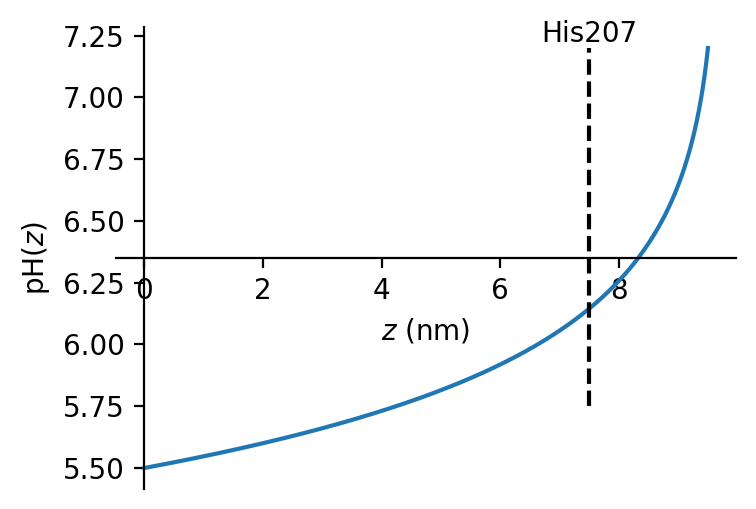

In [65]:
alpha = 1e-1
filename = f"figs/protondiffusion_L={Lmax}nm_D=tenthofbulk_kHmax.pdf"
plot_range("k_proton", (kH_max,), L_nm=Lmax, 
           bulk_pH=bulk_pH, D_proton=alpha * D_proton_bulk,
           filename=filename, legend=False)
plt.vlines(z_His207, 5.75, bulk_pH, color="k", linestyle="--")
plt.text(z_His207, bulk_pH, "His207", ha="center", va="bottom")
plt.savefig(filename)

The lowest pH is 5.5 at $z=0$ (by construction) and by assumption, still sufficient to support proton transport. The pH around the position of His207 is elevated to pH 6.15, which is around the pKa of His (6.0) and may be sufficient to change its protonation state.

In [66]:
c_His207 = c_clamped.subs(parameters).subs({z: z_His207})

In [67]:
pH_His207 = sm.N(to_pH.subs({n: c_His207}).subs(constants), 3)
print(f"At His207: pH {pH_His207}")

At His207: pH 6.15


## Summary

1. Proton efflux from the endosome to the cytosol is thermodynamically favorable.
2. If the proton efflux is mediated by the NHE6 cation/proton exchanger (antiporter) then export of one proton would be coupled to an import of one cation.
3. The proton gradient can drive energetically uphill import of sodium into the endosome. The potassium gradient (directed towards the endosome) can drive proton export. A simple model suggests that potassium/proton exchange is the primary transport cycle.  
1. If NHE6 were to run at full turnover _and_ proton diffusion away from the cytosolic exit is slowed down (due to localized titratable groups) then a very strong local pH gradient could be maintained. However, CPA typically only operate in a narrow pH activity window, which may limit the achievable pH gradient.
2. Even at 75 Å away from the transporter exit, the pH near His207 may be sufficiently different from the bulk to lead to a change in His protonation state.